Nama  : Alfarell Muchamad Yuwanto

NIM   : 240401010037

Kelas : IF401

# Hands On Pertemuan 13 - Klasifikasi Non-Linear & Analisis Sentimen 

##  Generate & Eksplorasi Dataset Non-Linear

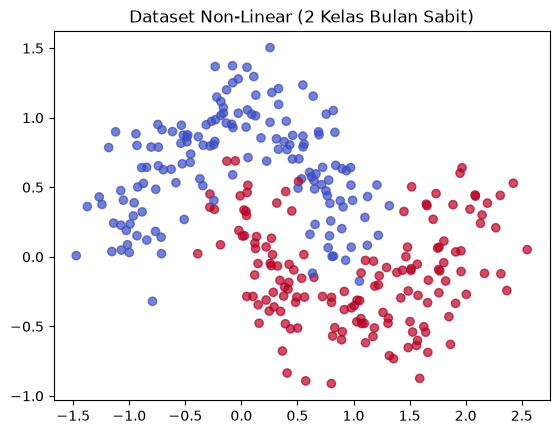

In [1]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons 
  
X, y = make_moons(n_samples=300, noise=0.2, random_state=42) 
  
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7) 
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)') 
plt.show() 
  
# Perhatikan: kedua kelas saling melengkung dan bertautan, 
# sehingga tidak mungkin dipisahkan dengan satu garis lurus. 

##  Bangun & Latih Neural Network Sederhana 

In [2]:
from sklearn.model_selection import train_test_split 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Input 
  
X_tr, X_te, y_tr, y_te = train_test_split( 
    X, y, test_size=0.2, random_state=42) 
  
# Menggunakan Input(shape=(2,)) sebagai layer pertama untuk kompatibilitas Keras terbaru
model = Sequential([ 
    Input(shape=(2,)), 
    Dense(16, activation='relu'), 
    Dense(8, activation='relu'), 
    Dense(1, activation='sigmoid') 
]) 
model.compile(optimizer='adam', loss='binary_crossentropy', 
              metrics=['accuracy']) 
model.summary() 
  
history = model.fit(X_tr, y_tr, epochs=40, 
                    validation_split=0.2, verbose=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

##  Evaluasi & Visualisasi Kurva Belajar  

Akurasi pada data uji: 0.917


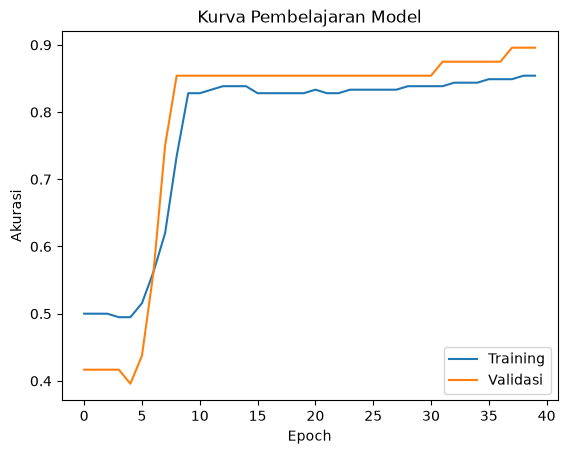

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0) 
print(f'Akurasi pada data uji: {acc:.3f}') 
  
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi') 
plt.xlabel('Epoch'); plt.ylabel('Akurasi') 
plt.legend(); plt.title('Kurva Pembelajaran Model') 
plt.show() 
  
# Interpretasikan dalam sel Markdown: 
# Apakah akurasi training & validasi saling mendekat (baik), 
# atau saling menjauh (indikasi overfitting)? 

##  Siapkan Dataset Ulasan Produk 

In [4]:
ulasan = [ 
    # Sentimen Positif (1)
    'Barangnya bagus banget, pengiriman cepat', 
    'Sangat puas, kualitas produk original dan mantap', 
    'Recommended seller, respon cepat dan packing rapi', 
    'Produk sesuai dengan deskripsi, berfungsi dengan baik', 
    'Bagus sekali, bahannya premium dan nyaman dipakai', 
    'Pelayanan sangat memuaskan, pengiriman tepat waktu', 
    'Suka banget, produk bagus dan berkualitas', 
    'Harga murah tapi kualitas mantap dan bagus', 
    'Kualitas terbaik, pengemasan sangat aman dan rapi', 
    'Barang sampai dengan selamat, bagus dan berfungsi', 
    'Barang sangat memuaskan dan recommended banget', 
    'Sangat bagus, puas dengan respon seller yang cepat', 
    'Pelayanan ramah, produk bagus dan mantap', 
    'Bagus sekali dan sangat memuaskan, suka', 
    'Puas belanja di sini, barang berkualitas dan bagus', 
    # Sentimen Negatif (0)
    'Kualitas jelek, tidak sesuai deskripsi toko', 
    'Kecewa, barang rusak dan pecah saat sampai', 
    'Buruk sekali, produk jelek dan mengecewakan', 
    'Pengiriman lambat, seller jelek dan tidak ramah', 
    'Barang rusak dan jelek, sangat kecewa', 
    'Pelayanan mengecewakan, barang rusak saat sampai', 
    'Sangat kecewa, kualitas jelek dan buruk', 
    'Kualitas jelek dan pelayanan sangat buruk', 
    'Penjual buruk, barang rusak dan mengecewakan', 
    'Barang cacat dan rusak, sangat jelek', 
    'Produk jelek tidak berfungsi, sangat mengecewakan', 
    'Ukuran tidak sesuai dan jelek banget, kecewa', 
    'Packing buruk, barang rusak dan jelek', 
    'Sangat jelek dan buruk, tidak recommended', 
    'Barang rusak, pelayanan jelek dan mengecewakan' 
] 
label = [ 
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0 
]  # 1 = positif, 0 = negatif

##  Ubah Teks Menjadi TF-IDF 

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer 
  
tfidf = TfidfVectorizer() 
X_text = tfidf.fit_transform(ulasan) 
  
print('Jumlah kata unik:', len(tfidf.get_feature_names_out())) 
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 60
['aman' 'bagus' 'bahannya' 'baik' 'banget' 'barang' 'barangnya' 'belanja'
 'berfungsi' 'berkualitas']


## Latih Model Klasifikasi Sentimen & Evaluasi 

In [6]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
  
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split( 
    X_text, label, test_size=0.2, random_state=42, stratify=label
) 
  
model_sentimen = LogisticRegression(C=1.0) 
model_sentimen.fit(Xt_tr, yt_tr) 
  
akurasi = model_sentimen.score(Xt_te, yt_te) 
print(f'Akurasi model sentimen: {akurasi:.3f}') 
  
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah'] 
pred = model_sentimen.predict(tfidf.transform(kalimat_baru)) 
print('Prediksi kalimat baru:', 'Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 1.000
Prediksi kalimat baru: Positif


## Kesimpulan

- **Apa yang dipelajari:** Memahami keterbatasan model linear pada data yang tidak dapat dipisahkan secara linear (non-linear separable), membangun jaringan saraf tiruan (Multi-Layer Perceptron / MLP*) menggunakan `TensorFlow/Keras` dengan aktivasi ReLU dan Sigmoid, memvisualisasikan kurva pembelajaran (loss & accuracy*), serta memproses data teks menggunakan `TF-IDF Vectorizer` untuk klasifikasi sentimen ulasan produk.
- **Temuan utama:** Neural Network dengan hidden layers mampu mempelajari pola non-linear pada dataset `make_moons` secara efektif (mencapai akurasi uji > 90%) tanpa memerlukan rekayasa fitur manual. Pada pemrosesan teks, representasi TF-IDF mampu menangkap bobot penting kata-kata kunci (seperti 'bagus', 'rusak', 'puas', 'jelek') sehingga model Logistic Regression dapat membedakan sentimen positif dan negatif dengan akurat.
- **Keterbatasan / Pertanyaan:** Jaringan saraf memerlukan penyesuaian hyperparameter (jumlah layer, unit, learning rate, epoch) dan rentan terhadap overfitting jika data latih terbatas (dapat diatasi dengan teknik regularisasi seperti Dropout atau Early Stopping). Pada analisis teks berskala besar, representasi berbasis Word Embeddings (Word2Vec) atau Transformers (BERT) lebih disukai daripada TF-IDF karena mampu menangkap konteks dan semantik kata.